In [33]:
import pandas as pd
import numpy as np
import torch
import torch_geometric

In [34]:
commit_info = pd.read_csv("../data/processed/commit_info.csv")
file_info = pd.read_csv("../data_new/processed/file_info_new.csv")
function_info = pd.read_csv("../data_new/processed/function_info_new.csv")
file_info.head()

,hash,commit_label,filename,old_path,new_path,change_type,diff,diff_parsed,num_lines_added,num_lines_deleted,code_after,code_before,num_method_changed,num_lines_of_code,complexity,token_count
0,462f35ad5de538cf5961806918a18c22add92c00,VCC,tpm_kdfa.c,src/tpm_kdfa.c,src/tpm_kdfa.c,MODIFY,NaN,NaN,0,0,NaN,//********************************************...,1,94,5,392
1,c5d72beaab1cbbbe68271f4bc4b6670d69985157,FC,tpm_kdfa.c,src/tpm_kdfa.c,lib/tpm_kdfa.c,MODIFY,NaN,NaN,0,0,//********************************************...,NaN,2,153,15,642
2,462f35ad5de538cf5961806918a18c22add92c00,VCC,tpm_kdfa.h,src/tpm_kdfa.h,src/tpm_kdfa.h,MODIFY,NaN,NaN,0,0,NaN,//********************************************...,0,49,0,0
3,c5d72beaab1cbbbe68271f4bc4b6670d69985157,FC,tpm_kdfa.h,src/tpm_kdfa.h,lib/tpm_kdfa.h,MODIFY,NaN,NaN,0,0,//********************************************...,NaN,0,49,0,0
4,462f35ad5de538cf5961806918a18c22add92c00,VCC,tpm_session.c,src/tpm_session.c,src/tpm_session.c,MODIFY,NaN,NaN,0,0,NaN,//********************************************...,5,267,26,1017


In [35]:
tensorflow_commits = commit_info[commit_info["repo_url"].str.contains("tensorflow", case=False, na=False)]
print(f"Total commits: {len(commit_info)}")
print(f"TensorFlow commits: {len(tensorflow_commits)}")
tensorflow_commits.head()

Total commits: 8796
TensorFlow commits: 835


,hash,msg,author,author_date,author_timezone,committer,committer_date,committer_timezone,in_main_branch,merge,...,num_lines_deleted,num_lines_added,num_lines_changed,num_files_changed,dmm_unit_size,dmm_unit_complexity,dmm_unit_interfacing,commit_type,cwe_id,repo_url
5935,15c609314179015e7c1bc1add9ccd141908dcdbc,Automated sync from github.com/tensorflow/tens...,41898282+github-actions[bot]@users.noreply.git...,2021-05-03 20:02:56+00:00,0,noreply@github.com,2021-05-03 20:02:56+00:00,0,True,False,...,0,526,526,6,0.508108,0.732432,0.772973,VCC,CWE-125,https://github.com/tensorflow/tflite-micro
5936,4142e47e9e31db481781b955ed3ff807a781b494,GatherNd verifies that an index is valid befor...,alankelly@google.com,2022-07-26 21:54:47+02:00,-7200,noreply@github.com,2022-07-26 19:54:47+00:00,0,True,False,...,12,51,63,2,0.666667,0.878788,0.666667,FC,CWE-125,https://github.com/tensorflow/tflite-micro
7814,2e465ed0d39c429c4fb292184d86a70432bf56ac,Merged commit includes the following changes:\...,gardener@tensorflow.org,2018-05-28 23:48:17-04:00,14400,gardener@tensorflow.org,2018-05-30 12:52:37-04:00,14400,True,False,...,0,6551,6551,38,0.169869,0.736810,0.852699,VCC,CWE-121,https://github.com/tensorflow/serving
7815,d6914ba17ff2557ad91809807d61699db18255cd,Accept integers in input requests where float/...,awk@google.com,2018-10-02 22:45:24-07:00,25200,gardener@tensorflow.org,2018-10-02 22:45:54-07:00,25200,True,False,...,71,174,245,3,0.088889,0.944444,0.944444,VCC,CWE-121,https://github.com/tensorflow/serving
7816,a17c89202e68bf19f369b9cbc97db7ced283b874,Add error messages for specific cases when jso...,charles.v@nssearch.com,2018-10-12 22:29:29-03:00,10800,charles.v@nssearch.com,2018-10-22 10:51:15-03:00,10800,True,False,...,14,40,54,2,0.000000,0.000000,0.440000,VCC,CWE-121,https://github.com/tensorflow/serving


In [36]:
# Commits with more than one file changed, filtered to tensorflow
tf_hashes = set(tensorflow_commits["hash"])
tf_file_info = file_info[file_info["hash"].isin(tf_hashes)]

files_per_commit = tf_file_info.groupby("hash")["filename"].count().reset_index()
files_per_commit.columns = ["hash", "num_files"]

multi_file_hashes = files_per_commit[files_per_commit["num_files"] > 1]["hash"]

# Join with commit_info to get temporal info and sort
multi_file_commits = tensorflow_commits[tensorflow_commits["hash"].isin(multi_file_hashes)].copy()
multi_file_commits = multi_file_commits.merge(files_per_commit, on="hash", how="left")
multi_file_commits["author_date"] = pd.to_datetime(multi_file_commits["author_date"], utc=True)
multi_file_commits = multi_file_commits.sort_values("author_date").reset_index(drop=True)

print(f"TensorFlow commits with > 1 file changed: {len(multi_file_commits)}")
multi_file_commits[["hash", "author_date", "num_files", "commit_type"]].head(20)


TensorFlow commits with > 1 file changed: 100


,hash,author_date,num_files,commit_type
0,4213ac97be449d0e40631a314d2b7bd3901d4967,2015-11-17 07:42:32+00:00,2,VCC
1,d552be23658b3bdd1b7dedd34f25631773e81dff,2016-01-22 17:55:02+00:00,2,VCC
2,8509f88ade3fc65f4cc530780d06100f0b1ea108,2016-02-26 18:22:06+00:00,2,VCC
3,6a187ccddaebb741ea77fc3201c6e36625f0aadb,2016-05-04 15:46:46+00:00,2,VCC
4,cc40cd3b0a8b83f5ee071b7ee32c17b56815a89c,2016-06-15 06:47:37+00:00,3,VCC
5,88686b308146887a88903c883bed7affc650e076,2016-08-08 20:27:33+00:00,2,VCC
6,0822c9393ab0610311c954ec370b5a8fe2397af7,2016-09-09 01:40:18+00:00,2,VCC
7,f803bd7c5338d522d262314bd1e0eb4021367c3d,2016-11-11 00:47:07+00:00,2,VCC
8,7abbdf2699d0c84e9c9fa2ffe9eb76d848d7be9f,2016-11-22 01:41:06+00:00,2,VCC
9,1e67c90e2caceeff82d09793d1ef5fa0300d219b,2017-01-09 20:04:37+00:00,2,VCC


In [ ]:
target_hash = "a5a51ad3a1200e2e5ef46c140bab717422e41ca2"

commit = commit_info[commit_info["hash"] == target_hash]
files = file_info[file_info["hash"] == target_hash]
functions = function_info[function_info["hash"] == target_hash]

print(f"Commit:\n"); display(commit)
print(f"\nFiles ({len(files)}):\n"); display(files)
print(f"\nFunctions ({len(functions)}):\n"); display(functions)


Commit:



,hash,msg,author,author_date,author_timezone,committer,committer_date,committer_timezone,in_main_branch,merge,...,num_lines_deleted,num_lines_added,num_lines_changed,num_files_changed,dmm_unit_size,dmm_unit_complexity,dmm_unit_interfacing,commit_type,cwe_id,repo_url
8082,982549ea3423df4270ff154e5c764beb43d472da,Branch 183429339 (#16469)\n\n* Change `reduce_...,rmlarsen@google.com,2018-01-26 13:32:16-08:00,28800,noreply@github.com,2018-01-26 13:32:16-08:00,28800,True,False,...,4414,4747,9161,325,0.773399,0.270936,0.837438,VCC,CWE-476,https://github.com/tensorflow/tensorflow



Files (5):



,hash,commit_label,filename,old_path,new_path,change_type,diff,diff_parsed,num_lines_added,num_lines_deleted,code_after,code_before,num_method_changed,num_lines_of_code,complexity,token_count
1668,982549ea3423df4270ff154e5c764beb43d472da,VCC,mfcc.cc,tensorflow/core/kernels/mfcc.cc,tensorflow/core/kernels/mfcc.cc,MODIFY,NaN,NaN,0,0,NaN,/* Copyright 2017 The TensorFlow Authors. All ...,3,65,6,200
5962,982549ea3423df4270ff154e5c764beb43d472da,VCC,sparse_matmul_op.cc,tensorflow/core/kernels/sparse_matmul_op.cc,tensorflow/core/kernels/sparse_matmul_op.cc,MODIFY,NaN,NaN,0,0,NaN,/* Copyright 2015 The TensorFlow Authors. All ...,53,1645,178,10202
7144,982549ea3423df4270ff154e5c764beb43d472da,VCC,sparse_sparse_binary_op_shared.cc,tensorflow/core/kernels/sparse_sparse_binary_o...,tensorflow/core/kernels/sparse_sparse_binary_o...,MODIFY,NaN,NaN,0,0,NaN,/* Copyright 2016 The TensorFlow Authors. All ...,3,241,17,1178
8083,982549ea3423df4270ff154e5c764beb43d472da,VCC,segment_reduction_ops.h,tensorflow/core/kernels/segment_reduction_ops.h,tensorflow/core/kernels/segment_reduction_ops.h,MODIFY,NaN,NaN,0,0,NaN,/* Copyright 2016 The TensorFlow Authors. All ...,2,104,2,58
10141,982549ea3423df4270ff154e5c764beb43d472da,VCC,nth_element_op.cc,tensorflow/core/kernels/nth_element_op.cc,tensorflow/core/kernels/nth_element_op.cc,MODIFY,NaN,NaN,0,0,NaN,/* Copyright 2015 The TensorFlow Authors. All ...,3,134,6,535



Functions (4):



,hash,commit_label,name,filename,num_lines_of_code,complexity,token_count,parameters,signature,start_line,end_line,length,top_nesting_level,code,before_change
1727,982549ea3423df4270ff154e5c764beb43d472da,VCC,tensorflow::Mfcc::Initialize,mfcc.cc,9,1,48,"['input_length', 'input_sample_rate']",tensorflow::Mfcc::Initialize( int input_length...,37,45,9,1,"bool Mfcc::Initialize(int input_length, double...",True
6441,982549ea3423df4270ff154e5c764beb43d472da,VCC,tensorflow::SparseMatMulOp::Compute,sparse_matmul_op.cc,86,16,872,['ctx'],tensorflow::SparseMatMulOp::Compute( OpKernelC...,959,1061,103,2,void Compute(OpKernelContext* ctx) override ...,True
7846,982549ea3423df4270ff154e5c764beb43d472da,VCC,tensorflow::SparseSparseBinaryOpShared::Compute,sparse_sparse_binary_op_shared.cc,87,8,829,['ctx'],tensorflow::SparseSparseBinaryOpShared::Comput...,123,226,104,2,void Compute(OpKernelContext *ctx) override ...,True
12010,982549ea3423df4270ff154e5c764beb43d472da,VCC,tensorflow::functor::NthElementFunctor::operat...,nth_element_op.cc,20,2,249,"['context', 'input_tensor', 'output_tensor', '...",tensorflow::functor::NthElementFunctor::operat...,87,121,35,3,"void operator()(OpKernelContext* context, co...",True


In [48]:
from torch_geometric.data import HeteroData
from itertools import combinations
import ast

# ── 1. Node feature tensors ──────────────────────────────────────────────────

commit_feat_cols = ["num_lines_deleted", "num_lines_added", "num_lines_changed",
                    "num_files_changed", "dmm_unit_size", "dmm_unit_complexity",
                    "dmm_unit_interfacing"]
file_feat_cols   = ["num_lines_added", "num_lines_deleted", "num_method_changed",
                    "num_lines_of_code", "complexity", "token_count"]
func_feat_cols   = ["num_lines_of_code", "complexity", "token_count",
                    "length", "top_nesting_level"]

commit_feats = commit[commit_feat_cols].fillna(0).values.astype("float32")
file_feats   = files[file_feat_cols].fillna(0).values.astype("float32")

# ── 2. Build local index maps ────────────────────────────────────────────────

files_reset = files.reset_index(drop=True)
filename_to_file_idx = {row["filename"]: i for i, row in files_reset.iterrows()}

functions_reset = functions.reset_index(drop=True)
has_functions = len(functions_reset) > 0

if has_functions:
    func_feats = functions_reset[func_feat_cols].fillna(0).values.astype("float32")
else:
    func_feats = np.zeros((0, len(func_feat_cols)), dtype=np.float32)

# ── 3. Edge index + features: commit → file ─────────────────────────────────

num_files_total = len(files_reset)
commit_to_file_src = torch.zeros(num_files_total, dtype=torch.long)
commit_to_file_dst = torch.arange(num_files_total, dtype=torch.long)
commit_to_file_edge = torch.stack([commit_to_file_src, commit_to_file_dst])

# Change type one-hot (ADD, MODIFY, DELETE, RENAME, COPY, UNKNOWN)
change_type_categories = ["ADD", "MODIFY", "DELETE", "RENAME", "COPY", "UNKNOWN"]
change_type_map = {ct: i for i, ct in enumerate(change_type_categories)}

commit_total_lines_added   = commit["num_lines_added"].fillna(0).values[0]
commit_total_lines_deleted = commit["num_lines_deleted"].fillna(0).values[0]
total_methods_changed      = files_reset["num_method_changed"].fillna(0).sum()

c2f_edge_feats = []
for _, frow in files_reset.iterrows():
    ct = frow.get("change_type", "UNKNOWN")
    one_hot = [0.0] * len(change_type_categories)
    idx = change_type_map.get(str(ct).upper(), change_type_map["UNKNOWN"])
    one_hot[idx] = 1.0

    lines_added_ratio   = frow["num_lines_added"]   / max(commit_total_lines_added, 1)
    lines_deleted_ratio = frow["num_lines_deleted"]  / max(commit_total_lines_deleted, 1)
    method_change_ratio = frow["num_method_changed"] / max(total_methods_changed, 1)

    old_p = str(frow.get("old_path", ""))
    new_p = str(frow.get("new_path", ""))
    path_changed = float(old_p != new_p and old_p != "" and new_p != "")

    c2f_edge_feats.append(one_hot + [lines_added_ratio, lines_deleted_ratio,
                                      method_change_ratio, path_changed])

c2f_edge_attr = torch.tensor(c2f_edge_feats, dtype=torch.float32)

# ── 4. Edge index + features: file → function (0:N — files may have no functions) ──

file_src, func_dst, f2fn_edge_feats = [], [], []

if has_functions:
    for func_idx, frow in functions_reset.iterrows():
        f_idx = filename_to_file_idx.get(frow["filename"])
        if f_idx is None:
            continue  # function's file not in this commit's file list
        file_src.append(f_idx)
        func_dst.append(func_idx)

        file_row = files_reset.iloc[f_idx]
        file_loc        = max(file_row["num_lines_of_code"], 1)
        file_complexity  = max(file_row["complexity"], 1)
        file_tokens      = max(file_row["token_count"], 1)

        loc_fraction     = frow["length"]       / file_loc
        complexity_ratio = frow["complexity"]    / file_complexity
        token_ratio      = frow["token_count"]  / file_tokens
        position         = frow["start_line"]   / file_loc

        try:
            params = ast.literal_eval(frow["parameters"]) if isinstance(frow["parameters"], str) else []
            num_params = float(len(params))
        except:
            num_params = 0.0

        bc = frow.get("before_change", "")
        before_change = 0.0
        if isinstance(bc, str) and bc.strip() != "":
            before_change = 1.0
        elif isinstance(bc, (int, float)) and not pd.isna(bc):
            before_change = float(bool(bc))

        f2fn_edge_feats.append([loc_fraction, complexity_ratio, token_ratio,
                               position, num_params, before_change])

if file_src:
    file_to_func_edge = torch.tensor([file_src, func_dst], dtype=torch.long)
    f2fn_edge_attr = torch.tensor(f2fn_edge_feats, dtype=torch.float32)
else:
    file_to_func_edge = torch.zeros((2, 0), dtype=torch.long)
    f2fn_edge_attr = torch.zeros((0, 6), dtype=torch.float32)

# ── 5. Co-modification edges: function ↔ function (same file, only if ≥2 funcs) ──

co_src, co_dst, co_feats = [], [], []

if has_functions:
    for f_idx, fname in enumerate(files_reset["filename"]):
        func_indices = [i for i, r in functions_reset.iterrows()
                        if r["filename"] == fname]
        if len(func_indices) < 2:
            continue  # need at least 2 functions for co-modification
        for a, b in combinations(func_indices, 2):
            fa, fb = functions_reset.iloc[a], functions_reset.iloc[b]
            file_loc = max(files_reset.iloc[f_idx]["num_lines_of_code"], 1)
            gap = abs(fa["start_line"] - fb["end_line"]) / file_loc
            proximity = 1.0 / (1.0 + gap)
            cplx_sim = 1.0 - abs(fa["complexity"] - fb["complexity"]) / max(fa["complexity"], fb["complexity"], 1)
            for s, d in [(a, b), (b, a)]:
                co_src.append(s)
                co_dst.append(d)
                co_feats.append([proximity, cplx_sim])

if co_src:
    co_mod_edge = torch.tensor([co_src, co_dst], dtype=torch.long)
    co_mod_attr = torch.tensor(co_feats, dtype=torch.float32)
else:
    co_mod_edge = torch.zeros((2, 0), dtype=torch.long)
    co_mod_attr = torch.zeros((0, 2), dtype=torch.float32)

# ── 6. Assemble HeteroData ───────────────────────────────────────────────────

data = HeteroData()

data["commit"].x   = torch.tensor(commit_feats)
data["file"].x     = torch.tensor(file_feats)
data["function"].x = torch.tensor(func_feats)

data["commit", "has", "file"].edge_index     = commit_to_file_edge
data["commit", "has", "file"].edge_attr      = c2f_edge_attr

data["file", "has", "function"].edge_index   = file_to_func_edge
data["file", "has", "function"].edge_attr    = f2fn_edge_attr

data["function", "co_modified", "function"].edge_index = co_mod_edge
data["function", "co_modified", "function"].edge_attr  = co_mod_attr

# ── Summary ──────────────────────────────────────────────────────────────────
files_with_funcs = len(set(file_src))
files_without_funcs = num_files_total - files_with_funcs

print(data)
print(f"\n{'='*60}")
print(f"Files: {num_files_total} total  ({files_with_funcs} with functions, {files_without_funcs} without)")
print(f"Functions: {len(functions_reset)} total")
print(f"\ncommit→file    edge_attr: {c2f_edge_attr.shape}  (change_type OH[6], lines_add_ratio, lines_del_ratio, method_ratio, path_changed)")
print(f"file→function  edge_attr: {f2fn_edge_attr.shape}  (loc_frac, complexity_ratio, token_ratio, position, num_params, before_change)")
print(f"func↔func      edge_attr: {co_mod_attr.shape}  (proximity, complexity_similarity)")


HeteroData(
  commit={ x=[1, 7] },
  file={ x=[5, 6] },
  function={ x=[4, 5] },
  (commit, has, file)={
    edge_index=[2, 5],
    edge_attr=[5, 10],
  },
  (file, has, function)={
    edge_index=[2, 4],
    edge_attr=[4, 6],
  },
  (function, co_modified, function)={
    edge_index=[2, 0],
    edge_attr=[0, 2],
  }
)

Files: 5 total  (4 with functions, 1 without)
Functions: 4 total

commit→file    edge_attr: torch.Size([5, 10])  (change_type OH[6], lines_add_ratio, lines_del_ratio, method_ratio, path_changed)
file→function  edge_attr: torch.Size([4, 6])  (loc_frac, complexity_ratio, token_ratio, position, num_params, before_change)
func↔func      edge_attr: torch.Size([0, 2])  (proximity, complexity_similarity)


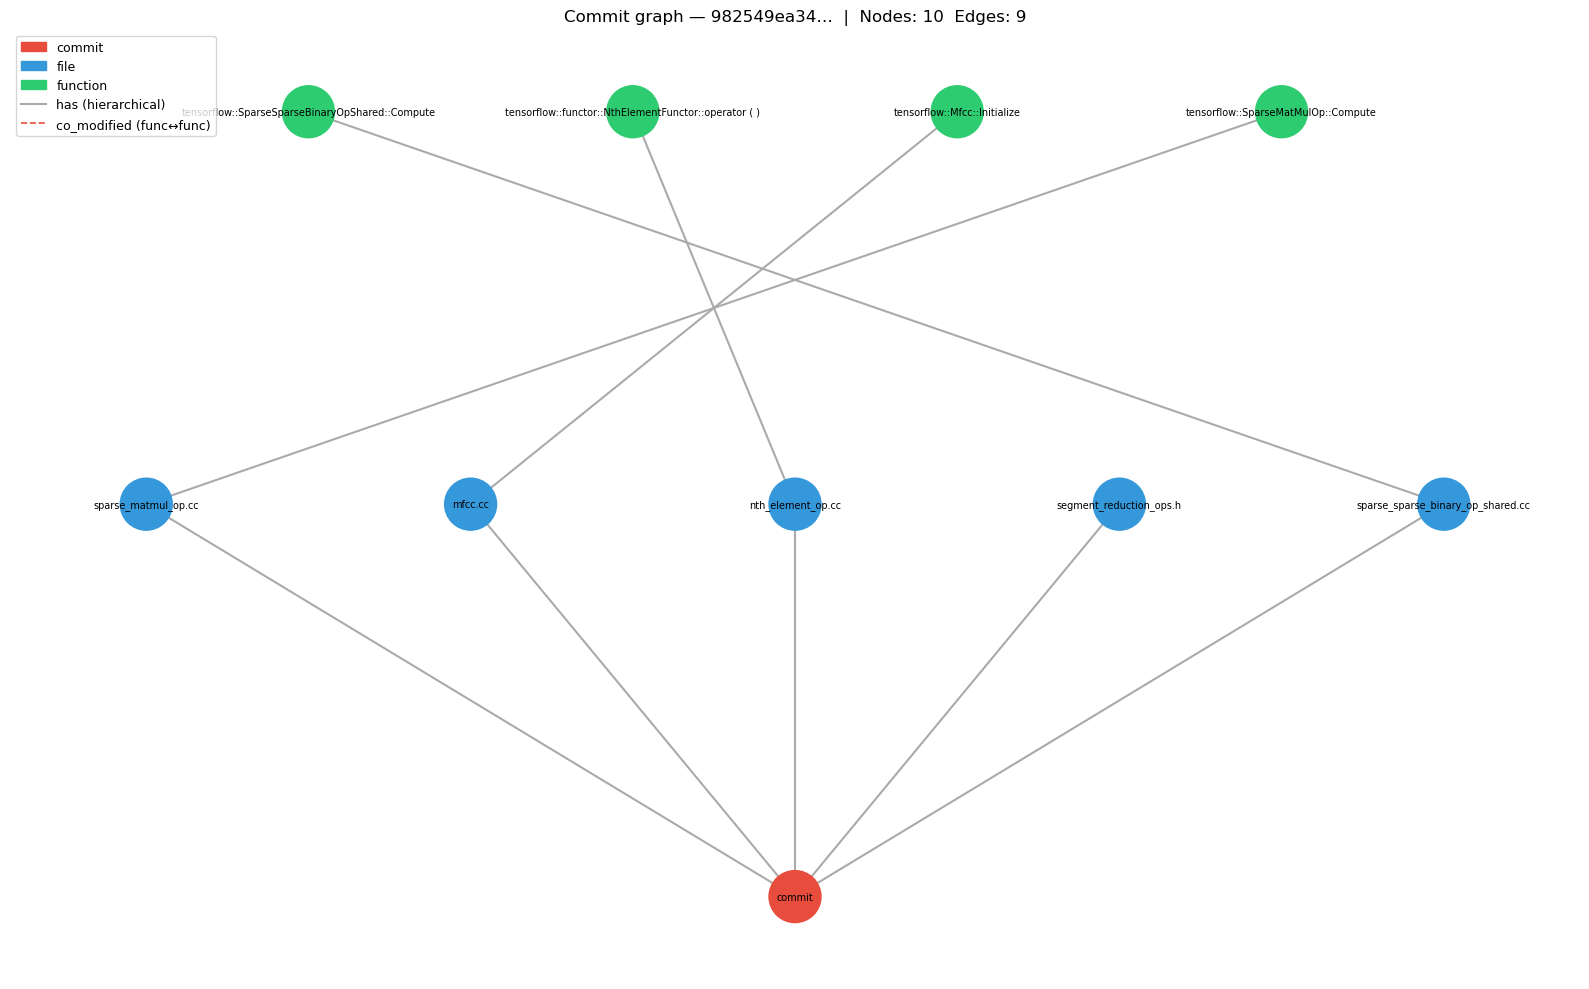

In [49]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

G = nx.DiGraph()

# ── Add nodes with type labels ───────────────────────────────────────────────
G.add_node("commit_0", node_type="commit", label="commit")

for i, row in files_reset.iterrows():
    G.add_node(f"file_{i}", node_type="file", label=row["filename"])

for i, row in functions_reset.iterrows():
    G.add_node(f"func_{i}", node_type="function", label=row["name"])

# ── Add edges with types ────────────────────────────────────────────────────
edge_colors_list = []

# commit → file
src, dst = commit_to_file_edge
for s, d in zip(src.tolist(), dst.tolist()):
    G.add_edge(f"commit_{s}", f"file_{d}", edge_type="has")
    edge_colors_list.append("#e67e22")  # orange

# file → function
src, dst = file_to_func_edge
for s, d in zip(src.tolist(), dst.tolist()):
    G.add_edge(f"file_{s}", f"func_{d}", edge_type="has")
    edge_colors_list.append("#8e44ad")  # purple

# function ↔ function (co-modification)
if co_mod_edge.shape[1] > 0:
    src, dst = co_mod_edge
    for s, d in zip(src.tolist(), dst.tolist()):
        key = (f"func_{s}", f"func_{d}")
        if not G.has_edge(*key):  # avoid duplicate visual edges
            G.add_edge(*key, edge_type="co_modified")
            edge_colors_list.append("#e74c3c")  # red dashed

# ── Layout ───────────────────────────────────────────────────────────────────
color_map = {"commit": "#e74c3c", "file": "#3498db", "function": "#2ecc71"}
node_colors = [color_map[G.nodes[n]["node_type"]] for n in G.nodes]
node_labels = {n: G.nodes[n]["label"] for n in G.nodes}

pos = nx.multipartite_layout(G, subset_key="node_type", scale=2, align="horizontal")

# ── Separate edges by type for different styles ──────────────────────────────
hier_edges = [(u, v) for u, v, d in G.edges(data=True) if d["edge_type"] == "has"]
co_edges   = [(u, v) for u, v, d in G.edges(data=True) if d["edge_type"] == "co_modified"]

fig, ax = plt.subplots(figsize=(16, 10))

# Draw hierarchical edges (solid)
nx.draw_networkx_edges(G, pos, edgelist=hier_edges, edge_color="#aaaaaa",
                       arrows=True, arrowsize=15, width=1.5, ax=ax)

# Draw co-modification edges (dashed red)
if co_edges:
    nx.draw_networkx_edges(G, pos, edgelist=co_edges, edge_color="#e74c3c",
                           arrows=True, arrowsize=12, width=1.2,
                           style="dashed", connectionstyle="arc3,rad=0.15", ax=ax)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1400, ax=ax)
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=7, ax=ax)

# ── Legend ───────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color="#e74c3c", label="commit"),
    mpatches.Patch(color="#3498db", label="file"),
    mpatches.Patch(color="#2ecc71", label="function"),
    plt.Line2D([0], [0], color="#aaaaaa", lw=1.5, label="has (hierarchical)"),
    plt.Line2D([0], [0], color="#e74c3c", lw=1.2, linestyle="dashed", label="co_modified (func↔func)"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=9)
ax.set_title(f"Commit graph — {target_hash[:10]}…  |  "
             f"Nodes: {G.number_of_nodes()}  Edges: {G.number_of_edges()}", fontsize=12)
ax.axis("off")
fig.tight_layout()
plt.show()


In [50]:
c2f_labels = ["ADD", "MODIFY", "DELETE", "RENAME", "COPY", "UNKNOWN",
              "lines_add_ratio", "lines_del_ratio", "method_ratio", "path_changed"]
f2fn_labels = ["loc_frac", "complexity_ratio", "token_ratio",
               "position", "num_params", "before_change"]
co_labels = ["proximity", "complexity_similarity"]

print("=" * 60)
print("COMMIT → FILE edge attributes")
print("=" * 60)
src, dst = commit_to_file_edge
for i in range(src.shape[0]):
    fname = files_reset.iloc[dst[i].item()]["filename"]
    vals = c2f_edge_attr[i]
    print(f"\n  commit → {fname}")
    for name, val in zip(c2f_labels, vals.tolist()):
        print(f"    {name:>20s}: {val:.4f}")

print(f"\n{'=' * 60}")
print("FILE → FUNCTION edge attributes")
print("=" * 60)
src, dst = file_to_func_edge
for i in range(src.shape[0]):
    fname = files_reset.iloc[src[i].item()]["filename"]
    func_name = functions_reset.iloc[dst[i].item()]["name"]
    vals = f2fn_edge_attr[i]
    print(f"\n  {fname} → {func_name}")
    for name, val in zip(f2fn_labels, vals.tolist()):
        print(f"    {name:>20s}: {val:.4f}")

if co_mod_edge.shape[1] > 0:
    print(f"\n{'=' * 60}")
    print("FUNCTION ↔ FUNCTION co-modification edge attributes")
    print("=" * 60)
    src, dst = co_mod_edge
    seen = set()
    for i in range(src.shape[0]):
        pair = (min(src[i].item(), dst[i].item()), max(src[i].item(), dst[i].item()))
        if pair in seen:
            continue
        seen.add(pair)
        fn_a = functions_reset.iloc[src[i].item()]["name"]
        fn_b = functions_reset.iloc[dst[i].item()]["name"]
        vals = co_mod_attr[i]
        print(f"\n  {fn_a} ↔ {fn_b}")
        for name, val in zip(co_labels, vals.tolist()):
            print(f"    {name:>25s}: {val:.4f}")


COMMIT → FILE edge attributes

  commit → mfcc.cc
                     ADD: 0.0000
                  MODIFY: 1.0000
                  DELETE: 0.0000
                  RENAME: 0.0000
                    COPY: 0.0000
                 UNKNOWN: 0.0000
         lines_add_ratio: 0.0000
         lines_del_ratio: 0.0000
            method_ratio: 0.0469
            path_changed: 0.0000

  commit → sparse_matmul_op.cc
                     ADD: 0.0000
                  MODIFY: 1.0000
                  DELETE: 0.0000
                  RENAME: 0.0000
                    COPY: 0.0000
                 UNKNOWN: 0.0000
         lines_add_ratio: 0.0000
         lines_del_ratio: 0.0000
            method_ratio: 0.8281
            path_changed: 0.0000

  commit → sparse_sparse_binary_op_shared.cc
                     ADD: 0.0000
                  MODIFY: 1.0000
                  DELETE: 0.0000
                  RENAME: 0.0000
                    COPY: 0.0000
                 UNKNOWN: 0.0000
         lines

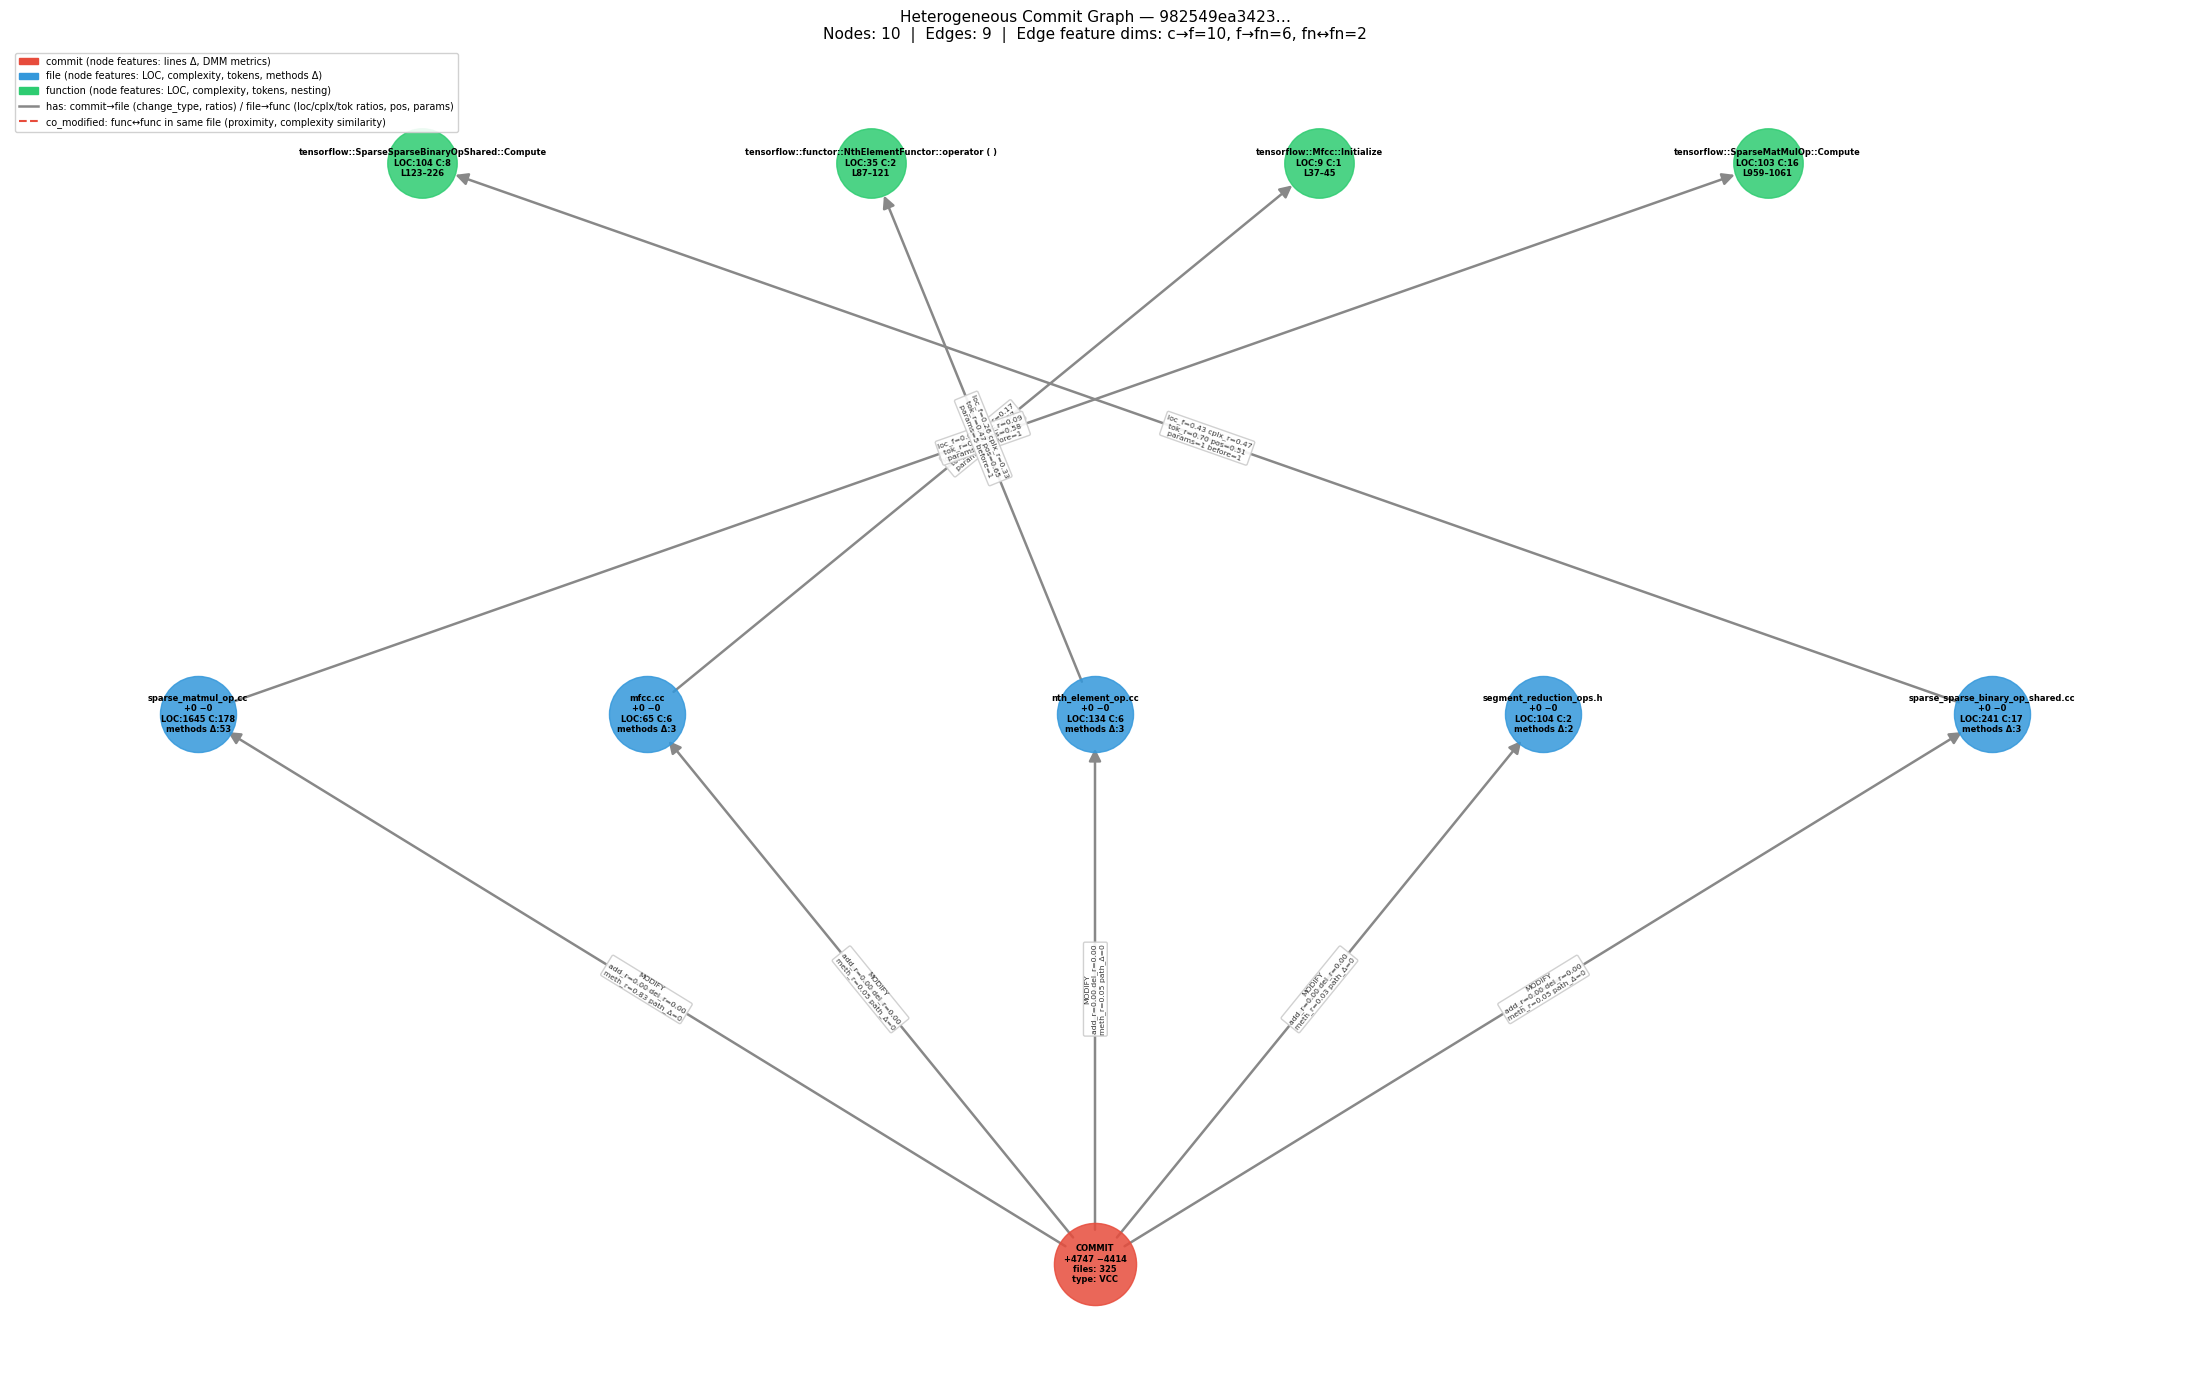

In [51]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from textwrap import fill

fig, ax = plt.subplots(figsize=(22, 14))

G2 = nx.DiGraph()

# ── Nodes ────────────────────────────────────────────────────────────────────
# Commit node — show key features inside label
c = commit.iloc[0]
commit_label = (f"COMMIT\n"
                f"+{int(c['num_lines_added'])} −{int(c['num_lines_deleted'])}\n"
                f"files: {int(c['num_files_changed'])}\n"
                f"type: {c['commit_type']}")
G2.add_node("commit_0", layer=0, label=commit_label)

# File nodes
for i, row in files_reset.iterrows():
    flabel = (f"{row['filename']}\n"
              f"+{int(row['num_lines_added'])} −{int(row['num_lines_deleted'])}\n"
              f"LOC:{int(row['num_lines_of_code'])} C:{int(row['complexity'])}\n"
              f"methods Δ:{int(row['num_method_changed'])}")
    G2.add_node(f"file_{i}", layer=1, label=flabel)

# Function nodes
for i, row in functions_reset.iterrows():
    func_label = (f"{row['name']}\n"
                  f"LOC:{int(row['length'])} C:{int(row['complexity'])}\n"
                  f"L{int(row['start_line'])}–{int(row['end_line'])}")
    G2.add_node(f"func_{i}", layer=2, label=func_label)

# ── Edges with annotation text ──────────────────────────────────────────────

# commit → file
c2f_meaningful = ["chg_type", "add_r", "del_r", "meth_r", "path_Δ"]
src, dst = commit_to_file_edge
for i in range(src.shape[0]):
    vals = c2f_edge_attr[i]
    # Find active change type
    ct_idx = vals[:6].argmax().item()
    ct_name = change_type_categories[ct_idx]
    annot = (f"{ct_name}\n"
             f"add_r={vals[6]:.2f} del_r={vals[7]:.2f}\n"
             f"meth_r={vals[8]:.2f} path_Δ={int(vals[9])}")
    G2.add_edge(f"commit_{src[i]}", f"file_{dst[i]}", label=annot, etype="has")

# file → function
src, dst = file_to_func_edge
for i in range(src.shape[0]):
    vals = f2fn_edge_attr[i]
    annot = (f"loc_f={vals[0]:.2f} cplx_r={vals[1]:.2f}\n"
             f"tok_r={vals[2]:.2f} pos={vals[3]:.2f}\n"
             f"params={int(vals[4])} before={int(vals[5])}")
    G2.add_edge(f"file_{src[i]}", f"func_{dst[i]}", label=annot, etype="has")

# function ↔ function (co-modification)
if co_mod_edge.shape[1] > 0:
    src, dst = co_mod_edge
    seen = set()
    for i in range(src.shape[0]):
        pair = (min(src[i].item(), dst[i].item()), max(src[i].item(), dst[i].item()))
        if pair in seen:
            continue
        seen.add(pair)
        vals = co_mod_attr[i]
        annot = f"prox={vals[0]:.2f}\ncplx_sim={vals[1]:.2f}"
        G2.add_edge(f"func_{src[i]}", f"func_{dst[i]}", label=annot, etype="co_mod")

# ── Layout ───────────────────────────────────────────────────────────────────
pos = nx.multipartite_layout(G2, subset_key="layer", scale=3, align="horizontal")

# Spread nodes vertically for readability
for node, (x, y) in pos.items():
    pos[node] = (x, y * 1.5)

# ── Draw nodes ───────────────────────────────────────────────────────────────
layer_colors = {0: "#e74c3c", 1: "#3498db", 2: "#2ecc71"}
layer_sizes  = {0: 3500, 1: 3000, 2: 2500}

for layer_id, color in layer_colors.items():
    nodes = [n for n, d in G2.nodes(data=True) if d["layer"] == layer_id]
    nx.draw_networkx_nodes(G2, pos, nodelist=nodes, node_color=color,
                           node_size=layer_sizes[layer_id], alpha=0.85, ax=ax)

node_labels = {n: d["label"] for n, d in G2.nodes(data=True)}
nx.draw_networkx_labels(G2, pos, labels=node_labels, font_size=6,
                        font_weight="bold", ax=ax)

# ── Draw hierarchical edges (solid) ─────────────────────────────────────────
hier = [(u, v) for u, v, d in G2.edges(data=True) if d["etype"] == "has"]
nx.draw_networkx_edges(G2, pos, edgelist=hier, edge_color="#888888",
                       arrows=True, arrowsize=18, width=1.8, ax=ax,
                       min_target_margin=25, min_source_margin=25)

# ── Draw co-mod edges (dashed red curved) ───────────────────────────────────
co = [(u, v) for u, v, d in G2.edges(data=True) if d["etype"] == "co_mod"]
if co:
    nx.draw_networkx_edges(G2, pos, edgelist=co, edge_color="#e74c3c",
                           arrows=True, arrowsize=14, width=1.5,
                           style="dashed", connectionstyle="arc3,rad=0.25",
                           ax=ax, min_target_margin=25, min_source_margin=25)

# ── Edge labels ──────────────────────────────────────────────────────────────
edge_labels = {(u, v): d["label"] for u, v, d in G2.edges(data=True)}
nx.draw_networkx_edge_labels(G2, pos, edge_labels=edge_labels,
                             font_size=5.5, font_color="#333333",
                             bbox=dict(boxstyle="round,pad=0.2",
                                       fc="white", ec="#cccccc", alpha=0.9),
                             ax=ax)

# ── Legend ───────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color="#e74c3c", label="commit (node features: lines Δ, DMM metrics)"),
    mpatches.Patch(color="#3498db", label="file (node features: LOC, complexity, tokens, methods Δ)"),
    mpatches.Patch(color="#2ecc71", label="function (node features: LOC, complexity, tokens, nesting)"),
    plt.Line2D([0], [0], color="#888888", lw=1.8,
               label="has: commit→file (change_type, ratios) / file→func (loc/cplx/tok ratios, pos, params)"),
    plt.Line2D([0], [0], color="#e74c3c", lw=1.5, linestyle="dashed",
               label="co_modified: func↔func in same file (proximity, complexity similarity)"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=7, framealpha=0.9)
ax.set_title(f"Heterogeneous Commit Graph — {target_hash[:12]}…\n"
             f"Nodes: {G2.number_of_nodes()}  |  Edges: {G2.number_of_edges()}  |  "
             f"Edge feature dims: c→f={c2f_edge_attr.shape[1]}, f→fn={f2fn_edge_attr.shape[1]}, fn↔fn={co_mod_attr.shape[1]}",
             fontsize=11)
ax.axis("off")
fig.tight_layout()
plt.show()


In [52]:
# Find commits that share files with the seed commit
seed_hash = "a5a51ad3a1200e2e5ef46c140bab717422e41ca2"
seed_files = set(file_info[file_info["hash"] == seed_hash]["filename"])
print(f"Seed commit files: {seed_files}")

# Find other TF commits that touch at least one of the same files
tf_file_subset = tf_file_info[tf_file_info["filename"].isin(seed_files)]
related_hashes = tf_file_subset[tf_file_subset["hash"] != seed_hash]["hash"].value_counts()
print(f"\nCommits sharing files with seed ({len(related_hashes)} found):")
display(related_hashes.head(10))


Seed commit files: {'conv_ops.cc', 'conv_grad_ops.cc'}

Commits sharing files with seed (11 found):


hash
b12aa1d44352de21d1a6faaf04172d8c2508b42b    1
bc6e0c471c4d7d6cd150149f2830e9d23a0040bc    1
3b9c747d71f30c6a59f6529f8475d7f56a86a7c5    1
19dd9342e7bc55c877367b7474caf41e819e38c3    1
e961e063a27863b0505b59219e38f83450a6831d    1
7b8db6083b34520688dbc71f341f7aeaf156bf17    1
e7f497570abb6b4ae5af4970620cd880e4c0c904    1
4213ac97be449d0e40631a314d2b7bd3901d4967    1
611d80db29dd7b0cfb755772c69d60ae5bca05f9    1
8722aeebdf823763596869a71eb6a7077bff7ccf    1
Name: count, dtype: int64

In [53]:
# ══════════════════════════════════════════════════════════════════════════════
# Multi-commit graph — 5 commits connected via shared files
# ══════════════════════════════════════════════════════════════════════════════

# Pick seed + top 4 related (by shared-file count)
selected_hashes = [seed_hash] + related_hashes.index.tolist()[:4]
print("Selected commits:")
for h in selected_hashes:
    row = commit_info[commit_info["hash"] == h].iloc[0]
    n_files = len(file_info[file_info["hash"] == h])
    n_funcs = len(function_info[function_info["hash"] == h])
    print(f"  {h[:12]}…  type={row['commit_type']}  files={n_files}  funcs={n_funcs}  date={row['author_date']}")

# Collect all data for selected commits
mc_commits = commit_info[commit_info["hash"].isin(selected_hashes)].copy()
mc_commits["author_date"] = pd.to_datetime(mc_commits["author_date"], utc=True)
mc_commits = mc_commits.sort_values("author_date").reset_index(drop=True)

mc_files = file_info[file_info["hash"].isin(selected_hashes)].reset_index(drop=True)
mc_functions = function_info[function_info["hash"].isin(selected_hashes)].reset_index(drop=True)

print(f"\nTotal: {len(mc_commits)} commits, {len(mc_files)} files, {len(mc_functions)} functions")


Selected commits:
  a5a51ad3a120…  type=VCC  files=2  funcs=2  date=2018-04-30 06:59:23-07:00
  b12aa1d44352…  type=FC  files=1  funcs=1  date=2021-04-19 18:32:56-07:00
  bc6e0c471c4d…  type=VCC  files=1  funcs=1  date=2017-03-15 16:22:16-08:00
  3b9c747d71f3…  type=VCC  files=1  funcs=1  date=2018-09-26 16:40:44-07:00
  19dd9342e7bc…  type=VCC  files=1  funcs=0  date=2017-03-06 12:21:14-08:00

Total: 5 commits, 6 files, 5 functions


In [54]:
# ══════════════════════════════════════════════════════════════════════════════
# Build multi-commit HeteroData with cross-commit connections
# ══════════════════════════════════════════════════════════════════════════════

from torch_geometric.data import HeteroData
from itertools import combinations
import ast

# ── Global index maps ────────────────────────────────────────────────────────
# Commits: indexed by mc_commits row order (sorted by date)
commit_hash_to_idx = {row["hash"]: i for i, row in mc_commits.iterrows()}

# Files: deduplicated by filename — shared files get one node
all_filenames = mc_files["filename"].unique()
filename_to_global_idx = {fn: i for i, fn in enumerate(all_filenames)}

# Functions: global index across all commits
mc_functions_global = mc_functions.reset_index(drop=True)
num_global_funcs = len(mc_functions_global)

# ── 1. Node features ────────────────────────────────────────────────────────

commit_feat_cols = ["num_lines_deleted", "num_lines_added", "num_lines_changed",
                    "num_files_changed", "dmm_unit_size", "dmm_unit_complexity",
                    "dmm_unit_interfacing"]
file_feat_cols   = ["num_lines_added", "num_lines_deleted", "num_method_changed",
                    "num_lines_of_code", "complexity", "token_count"]
func_feat_cols   = ["num_lines_of_code", "complexity", "token_count",
                    "length", "top_nesting_level"]

mc_commit_feats = mc_commits[commit_feat_cols].fillna(0).values.astype("float32")

# For shared file nodes: aggregate features across commits (mean)
mc_file_feats = np.zeros((len(all_filenames), len(file_feat_cols)), dtype=np.float32)
for fn in all_filenames:
    rows = mc_files[mc_files["filename"] == fn][file_feat_cols].fillna(0)
    mc_file_feats[filename_to_global_idx[fn]] = rows.mean().values.astype("float32")

if num_global_funcs > 0:
    mc_func_feats = mc_functions_global[func_feat_cols].fillna(0).values.astype("float32")
else:
    mc_func_feats = np.zeros((0, len(func_feat_cols)), dtype=np.float32)

# ── 2. Edge: commit → file ──────────────────────────────────────────────────

c2f_src, c2f_dst, c2f_feats = [], [], []
change_type_categories = ["ADD", "MODIFY", "DELETE", "RENAME", "COPY", "UNKNOWN"]
change_type_map = {ct: i for i, ct in enumerate(change_type_categories)}

for ci, crow in mc_commits.iterrows():
    h = crow["hash"]
    commit_files = mc_files[mc_files["hash"] == h]
    total_add = max(crow["num_lines_added"], 1)
    total_del = max(crow["num_lines_deleted"], 1)
    total_meth = max(commit_files["num_method_changed"].fillna(0).sum(), 1)

    for _, frow in commit_files.iterrows():
        fi = filename_to_global_idx[frow["filename"]]
        c2f_src.append(ci)
        c2f_dst.append(fi)

        ct = str(frow.get("change_type", "UNKNOWN")).upper()
        one_hot = [0.0] * 6
        one_hot[change_type_map.get(ct, 5)] = 1.0

        c2f_feats.append(one_hot + [
            frow["num_lines_added"] / total_add,
            frow["num_lines_deleted"] / total_del,
            frow["num_method_changed"] / total_meth,
            float(str(frow.get("old_path", "")) != str(frow.get("new_path", "")))
        ])

mc_c2f_edge = torch.tensor([c2f_src, c2f_dst], dtype=torch.long)
mc_c2f_attr = torch.tensor(c2f_feats, dtype=torch.float32)

# ── 3. Edge: file → function ────────────────────────────────────────────────

f2fn_src, f2fn_dst, f2fn_feats = [], [], []

if num_global_funcs > 0:
    for gi, frow in mc_functions_global.iterrows():
        fi = filename_to_global_idx.get(frow["filename"])
        if fi is None:
            continue
        f2fn_src.append(fi)
        f2fn_dst.append(gi)

        file_loc   = max(mc_file_feats[fi][3], 1)  # num_lines_of_code
        file_cplx  = max(mc_file_feats[fi][4], 1)  # complexity
        file_tok   = max(mc_file_feats[fi][5], 1)  # token_count

        try:
            params = ast.literal_eval(frow["parameters"]) if isinstance(frow["parameters"], str) else []
            num_params = float(len(params))
        except:
            num_params = 0.0

        bc = frow.get("before_change", "")
        before_change = 0.0
        if isinstance(bc, str) and bc.strip() != "":
            before_change = 1.0
        elif isinstance(bc, (int, float)) and not pd.isna(bc):
            before_change = float(bool(bc))

        f2fn_feats.append([
            frow["length"] / file_loc,
            frow["complexity"] / file_cplx,
            frow["token_count"] / file_tok,
            frow["start_line"] / file_loc,
            num_params,
            before_change
        ])

if f2fn_src:
    mc_f2fn_edge = torch.tensor([f2fn_src, f2fn_dst], dtype=torch.long)
    mc_f2fn_attr = torch.tensor(f2fn_feats, dtype=torch.float32)
else:
    mc_f2fn_edge = torch.zeros((2, 0), dtype=torch.long)
    mc_f2fn_attr = torch.zeros((0, 6), dtype=torch.float32)

# ── 4. Edge: function ↔ function (co-modified in same file & commit) ────────

co_src, co_dst, co_feats = [], [], []
if num_global_funcs > 0:
    for h in selected_hashes:
        h_funcs = mc_functions_global[mc_functions_global["hash"] == h]
        for fn in h_funcs["filename"].unique():
            fn_indices = h_funcs[h_funcs["filename"] == fn].index.tolist()
            if len(fn_indices) < 2:
                continue
            for a, b in combinations(fn_indices, 2):
                fa, fb = mc_functions_global.iloc[a], mc_functions_global.iloc[b]
                fi = filename_to_global_idx[fn]
                fl = max(mc_file_feats[fi][3], 1)
                gap = abs(fa["start_line"] - fb["end_line"]) / fl
                proximity = 1.0 / (1.0 + gap)
                cplx_sim = 1.0 - abs(fa["complexity"] - fb["complexity"]) / max(fa["complexity"], fb["complexity"], 1)
                for s, d in [(a, b), (b, a)]:
                    co_src.append(s); co_dst.append(d)
                    co_feats.append([proximity, cplx_sim])

if co_src:
    mc_co_edge = torch.tensor([co_src, co_dst], dtype=torch.long)
    mc_co_attr = torch.tensor(co_feats, dtype=torch.float32)
else:
    mc_co_edge = torch.zeros((2, 0), dtype=torch.long)
    mc_co_attr = torch.zeros((0, 2), dtype=torch.float32)

# ── 5. NEW: commit ↔ commit (temporal sequence) ─────────────────────────────
# Commits are sorted by date → chain them with time-gap features

temp_src, temp_dst, temp_feats = [], [], []
for i in range(len(mc_commits) - 1):
    dt_a = mc_commits.iloc[i]["author_date"]
    dt_b = mc_commits.iloc[i + 1]["author_date"]
    days_gap = abs((dt_b - dt_a).total_seconds()) / 86400.0

    # Same author?
    same_author = float(mc_commits.iloc[i]["author"] == mc_commits.iloc[i + 1]["author"])
    # Same commit type?
    same_type = float(mc_commits.iloc[i]["commit_type"] == mc_commits.iloc[i + 1]["commit_type"])

    # Both directions
    for s, d in [(i, i + 1), (i + 1, i)]:
        temp_src.append(s); temp_dst.append(d)
        temp_feats.append([days_gap, same_author, same_type])

mc_temp_edge = torch.tensor([temp_src, temp_dst], dtype=torch.long)
mc_temp_attr = torch.tensor(temp_feats, dtype=torch.float32)

# ── 6. Assemble HeteroData ──────────────────────────────────────────────────

mc_data = HeteroData()

mc_data["commit"].x   = torch.tensor(mc_commit_feats)
mc_data["file"].x     = torch.tensor(mc_file_feats)
mc_data["function"].x = torch.tensor(mc_func_feats)

mc_data["commit", "has", "file"].edge_index             = mc_c2f_edge
mc_data["commit", "has", "file"].edge_attr              = mc_c2f_attr

mc_data["file", "has", "function"].edge_index           = mc_f2fn_edge
mc_data["file", "has", "function"].edge_attr            = mc_f2fn_attr

mc_data["function", "co_modified", "function"].edge_index = mc_co_edge
mc_data["function", "co_modified", "function"].edge_attr  = mc_co_attr

mc_data["commit", "temporal", "commit"].edge_index      = mc_temp_edge
mc_data["commit", "temporal", "commit"].edge_attr       = mc_temp_attr

print(mc_data)
print(f"\n{'='*70}")
print(f"commit→file       : {mc_c2f_edge.shape[1]} edges, attr {mc_c2f_attr.shape}")
print(f"file→function     : {mc_f2fn_edge.shape[1]} edges, attr {mc_f2fn_attr.shape}")
print(f"func↔func co_mod  : {mc_co_edge.shape[1]} edges, attr {mc_co_attr.shape}")
print(f"commit↔commit temp: {mc_temp_edge.shape[1]} edges, attr {mc_temp_attr.shape}")

# Show inter-commit connections via shared files
print(f"\n{'='*70}")
print("Shared file connections (commits linked through same file node):")
for fn in all_filenames:
    touching = mc_files[mc_files["filename"] == fn]["hash"].unique()
    if len(touching) > 1:
        print(f"  {fn} → shared by {len(touching)} commits: {[h[:10]+'…' for h in touching]}")


HeteroData(
  commit={ x=[5, 7] },
  file={ x=[2, 6] },
  function={ x=[5, 5] },
  (commit, has, file)={
    edge_index=[2, 6],
    edge_attr=[6, 10],
  },
  (file, has, function)={
    edge_index=[2, 5],
    edge_attr=[5, 6],
  },
  (function, co_modified, function)={
    edge_index=[2, 0],
    edge_attr=[0, 2],
  },
  (commit, temporal, commit)={
    edge_index=[2, 8],
    edge_attr=[8, 3],
  }
)

commit→file       : 6 edges, attr torch.Size([6, 10])
file→function     : 5 edges, attr torch.Size([5, 6])
func↔func co_mod  : 0 edges, attr torch.Size([0, 2])
commit↔commit temp: 8 edges, attr torch.Size([8, 3])

Shared file connections (commits linked through same file node):
  conv_ops.cc → shared by 4 commits: ['a5a51ad3a1…', 'b12aa1d443…', 'bc6e0c471c…', '3b9c747d71…']
  conv_grad_ops.cc → shared by 2 commits: ['a5a51ad3a1…', '19dd9342e7…']


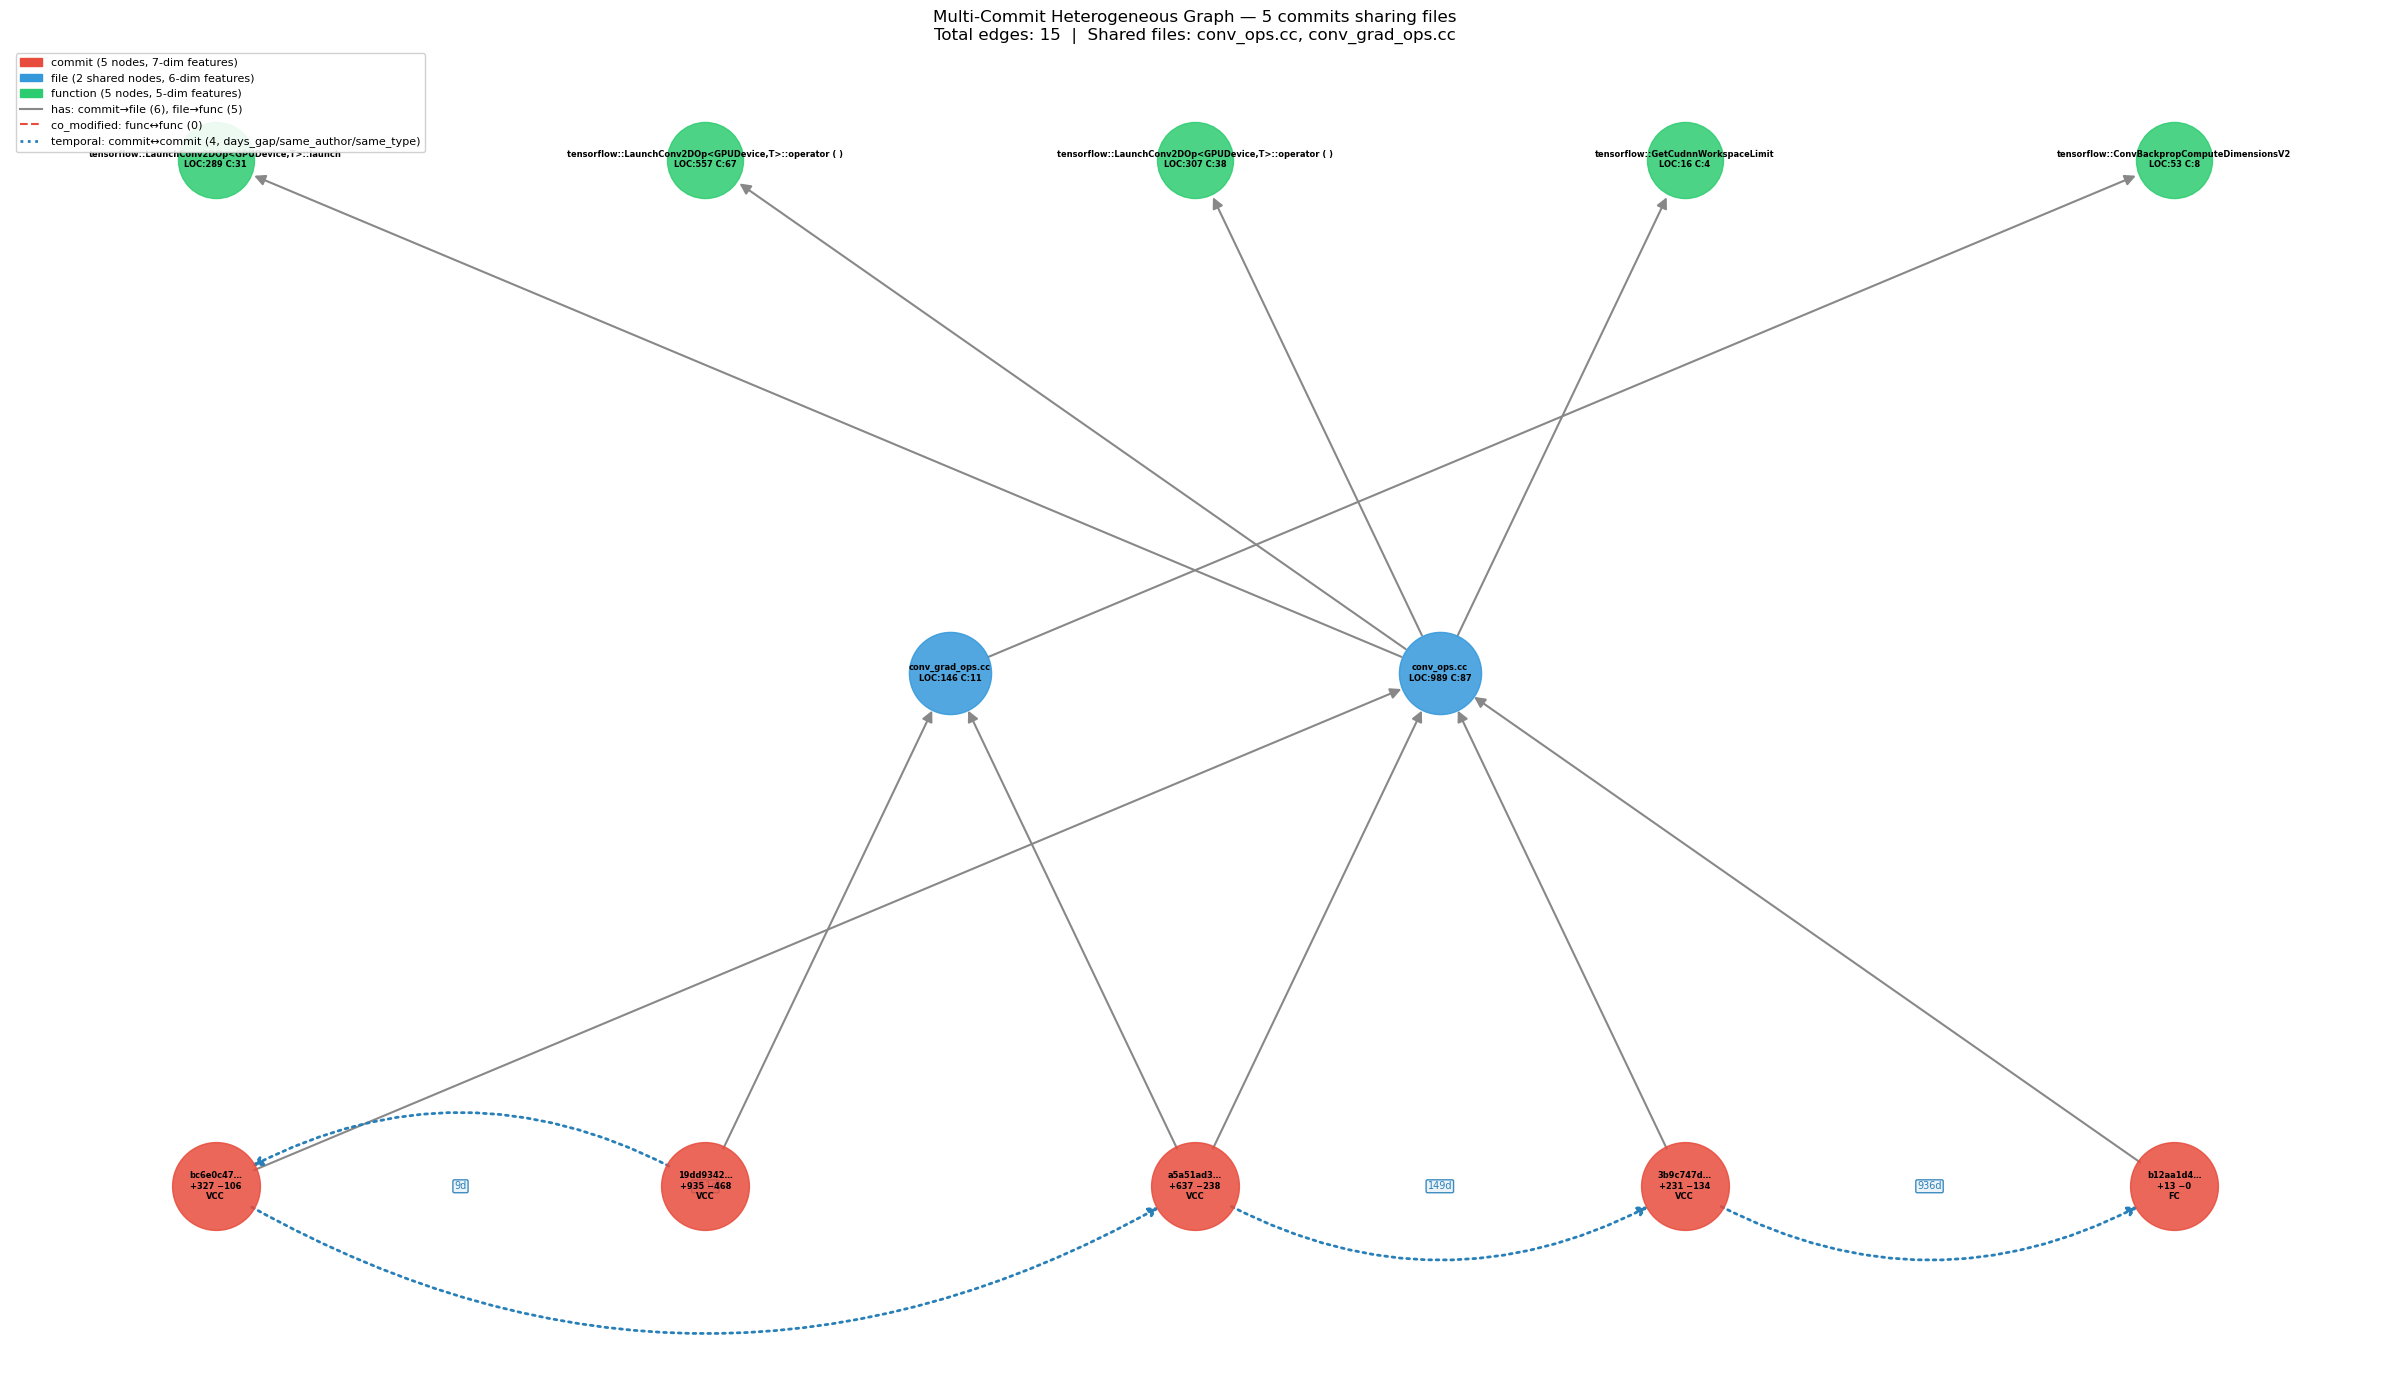

In [55]:
# ══════════════════════════════════════════════════════════════════════════════
# Visualize the multi-commit heterogeneous graph
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

G3 = nx.DiGraph()

# ── Commit nodes ─────────────────────────────────────────────────────────────
for i, row in mc_commits.iterrows():
    label = (f"{row['hash'][:8]}…\n"
             f"+{int(row['num_lines_added'])} −{int(row['num_lines_deleted'])}\n"
             f"{row['commit_type']}")
    G3.add_node(f"commit_{i}", layer=0, label=label)

# ── File nodes (deduplicated) ────────────────────────────────────────────────
for fn, fi in filename_to_global_idx.items():
    label = f"{fn}\nLOC:{int(mc_file_feats[fi][3])} C:{int(mc_file_feats[fi][4])}"
    G3.add_node(f"file_{fi}", layer=1, label=label)

# ── Function nodes ───────────────────────────────────────────────────────────
for i, row in mc_functions_global.iterrows():
    label = (f"{row['name']}\n"
             f"LOC:{int(row['length'])} C:{int(row['complexity'])}")
    G3.add_node(f"func_{i}", layer=2, label=label)

# ── Edges ────────────────────────────────────────────────────────────────────

# commit → file (solid gray)
src, dst = mc_c2f_edge
for s, d in zip(src.tolist(), dst.tolist()):
    ct_idx = mc_c2f_attr[s][:6].argmax().item() if s < len(mc_c2f_attr) else 5
    G3.add_edge(f"commit_{s}", f"file_{d}", etype="has")

# file → function (solid gray)
if mc_f2fn_edge.shape[1] > 0:
    src, dst = mc_f2fn_edge
    for s, d in zip(src.tolist(), dst.tolist()):
        G3.add_edge(f"file_{s}", f"func_{d}", etype="has")

# func ↔ func co-modification (dashed red)
if mc_co_edge.shape[1] > 0:
    src, dst = mc_co_edge
    seen = set()
    for s, d in zip(src.tolist(), dst.tolist()):
        pair = (min(s, d), max(s, d))
        if pair not in seen:
            seen.add(pair)
            G3.add_edge(f"func_{s}", f"func_{d}", etype="co_mod")

# commit ↔ commit temporal (dotted blue)
src, dst = mc_temp_edge
seen = set()
for i, (s, d) in enumerate(zip(src.tolist(), dst.tolist())):
    pair = (min(s, d), max(s, d))
    if pair not in seen:
        seen.add(pair)
        days = mc_temp_attr[i][0].item()
        G3.add_edge(f"commit_{s}", f"commit_{d}", etype="temporal",
                    label=f"{days:.0f}d")

# ── Layout ───────────────────────────────────────────────────────────────────
pos = nx.multipartite_layout(G3, subset_key="layer", scale=4, align="horizontal")
for node, (x, y) in pos.items():
    pos[node] = (x, y * 2.0)

fig, ax = plt.subplots(figsize=(24, 14))

# ── Draw edges by type ──────────────────────────────────────────────────────
has_edges = [(u, v) for u, v, d in G3.edges(data=True) if d["etype"] == "has"]
co_edges  = [(u, v) for u, v, d in G3.edges(data=True) if d["etype"] == "co_mod"]
temp_edges = [(u, v) for u, v, d in G3.edges(data=True) if d["etype"] == "temporal"]

nx.draw_networkx_edges(G3, pos, edgelist=has_edges, edge_color="#888888",
                       arrows=True, arrowsize=16, width=1.5, ax=ax,
                       min_target_margin=30, min_source_margin=30)

if co_edges:
    nx.draw_networkx_edges(G3, pos, edgelist=co_edges, edge_color="#e74c3c",
                           arrows=False, width=1.5, style="dashed",
                           connectionstyle="arc3,rad=0.2", ax=ax,
                           min_target_margin=30, min_source_margin=30)

if temp_edges:
    nx.draw_networkx_edges(G3, pos, edgelist=temp_edges, edge_color="#2980b9",
                           arrows=True, arrowsize=14, width=2.0, style="dotted",
                           connectionstyle="arc3,rad=0.3", ax=ax,
                           min_target_margin=30, min_source_margin=30)
    # Label temporal edges with day gaps
    temp_labels = {(u, v): d.get("label", "") for u, v, d in G3.edges(data=True)
                   if d["etype"] == "temporal"}
    nx.draw_networkx_edge_labels(G3, pos, edge_labels=temp_labels,
                                 font_size=7, font_color="#2980b9",
                                 bbox=dict(boxstyle="round,pad=0.15",
                                           fc="#eaf2f8", ec="#2980b9", alpha=0.9),
                                 ax=ax)

# ── Draw nodes ───────────────────────────────────────────────────────────────
layer_cfg = {
    0: ("#e74c3c", 4000, "commit"),
    1: ("#3498db", 3500, "file"),
    2: ("#2ecc71", 3000, "function"),
}
for layer_id, (color, size, _) in layer_cfg.items():
    nodes = [n for n, d in G3.nodes(data=True) if d["layer"] == layer_id]
    nx.draw_networkx_nodes(G3, pos, nodelist=nodes, node_color=color,
                           node_size=size, alpha=0.85, ax=ax)

labels = {n: d["label"] for n, d in G3.nodes(data=True)}
nx.draw_networkx_labels(G3, pos, labels=labels, font_size=6,
                        font_weight="bold", ax=ax)

# ── Legend ───────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color="#e74c3c", label=f"commit ({len(mc_commits)} nodes, 7-dim features)"),
    mpatches.Patch(color="#3498db", label=f"file ({len(all_filenames)} shared nodes, 6-dim features)"),
    mpatches.Patch(color="#2ecc71", label=f"function ({num_global_funcs} nodes, 5-dim features)"),
    plt.Line2D([0], [0], color="#888888", lw=1.5,
               label=f"has: commit→file ({mc_c2f_edge.shape[1]}), file→func ({mc_f2fn_edge.shape[1]})"),
    plt.Line2D([0], [0], color="#e74c3c", lw=1.5, linestyle="dashed",
               label=f"co_modified: func↔func ({mc_co_edge.shape[1] // 2})"),
    plt.Line2D([0], [0], color="#2980b9", lw=2.0, linestyle="dotted",
               label=f"temporal: commit↔commit ({mc_temp_edge.shape[1] // 2}, days_gap/same_author/same_type)"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=8, framealpha=0.9)
ax.set_title(f"Multi-Commit Heterogeneous Graph — {len(mc_commits)} commits sharing files\n"
             f"Total edges: {G3.number_of_edges()}  |  "
             f"Shared files: {', '.join(fn for fn in all_filenames if len(mc_files[mc_files['filename']==fn]['hash'].unique()) > 1)}",
             fontsize=12)
ax.axis("off")
fig.tight_layout()
plt.show()


In [56]:
# ══════════════════════════════════════════════════════════════════════════════
# Understand current TF dataset
# ══════════════════════════════════════════════════════════════════════════════

print("TF commits by type:")
print(tensorflow_commits["commit_type"].value_counts())

# Files touched by TF VCCs and FCs
tf_vcc = tensorflow_commits[tensorflow_commits["commit_type"] == "VCC"]
tf_fc  = tensorflow_commits[tensorflow_commits["commit_type"] == "FC"]

vcc_files = set(file_info[file_info["hash"].isin(tf_vcc["hash"])]["filename"])
fc_files  = set(file_info[file_info["hash"].isin(tf_fc["hash"])]["filename"])
all_security_files = vcc_files | fc_files

print(f"\nVCC commits: {len(tf_vcc)}, FC commits: {len(tf_fc)}")
print(f"Unique files in VCCs: {len(vcc_files)}")
print(f"Unique files in FCs: {len(fc_files)}")
print(f"Files in both VCC & FC: {len(vcc_files & fc_files)}")
print(f"All security-relevant files: {len(all_security_files)}")

# Date range
tf_dates = pd.to_datetime(tensorflow_commits["author_date"], utc=True)
print(f"\nDate range: {tf_dates.min().date()} → {tf_dates.max().date()}")


TF commits by type:
commit_type
VCC    473
FC     362
Name: count, dtype: int64

VCC commits: 473, FC commits: 362
Unique files in VCCs: 260
Unique files in FCs: 305
Files in both VCC & FC: 257
All security-relevant files: 308

Date range: 2015-11-17 → 2024-08-06


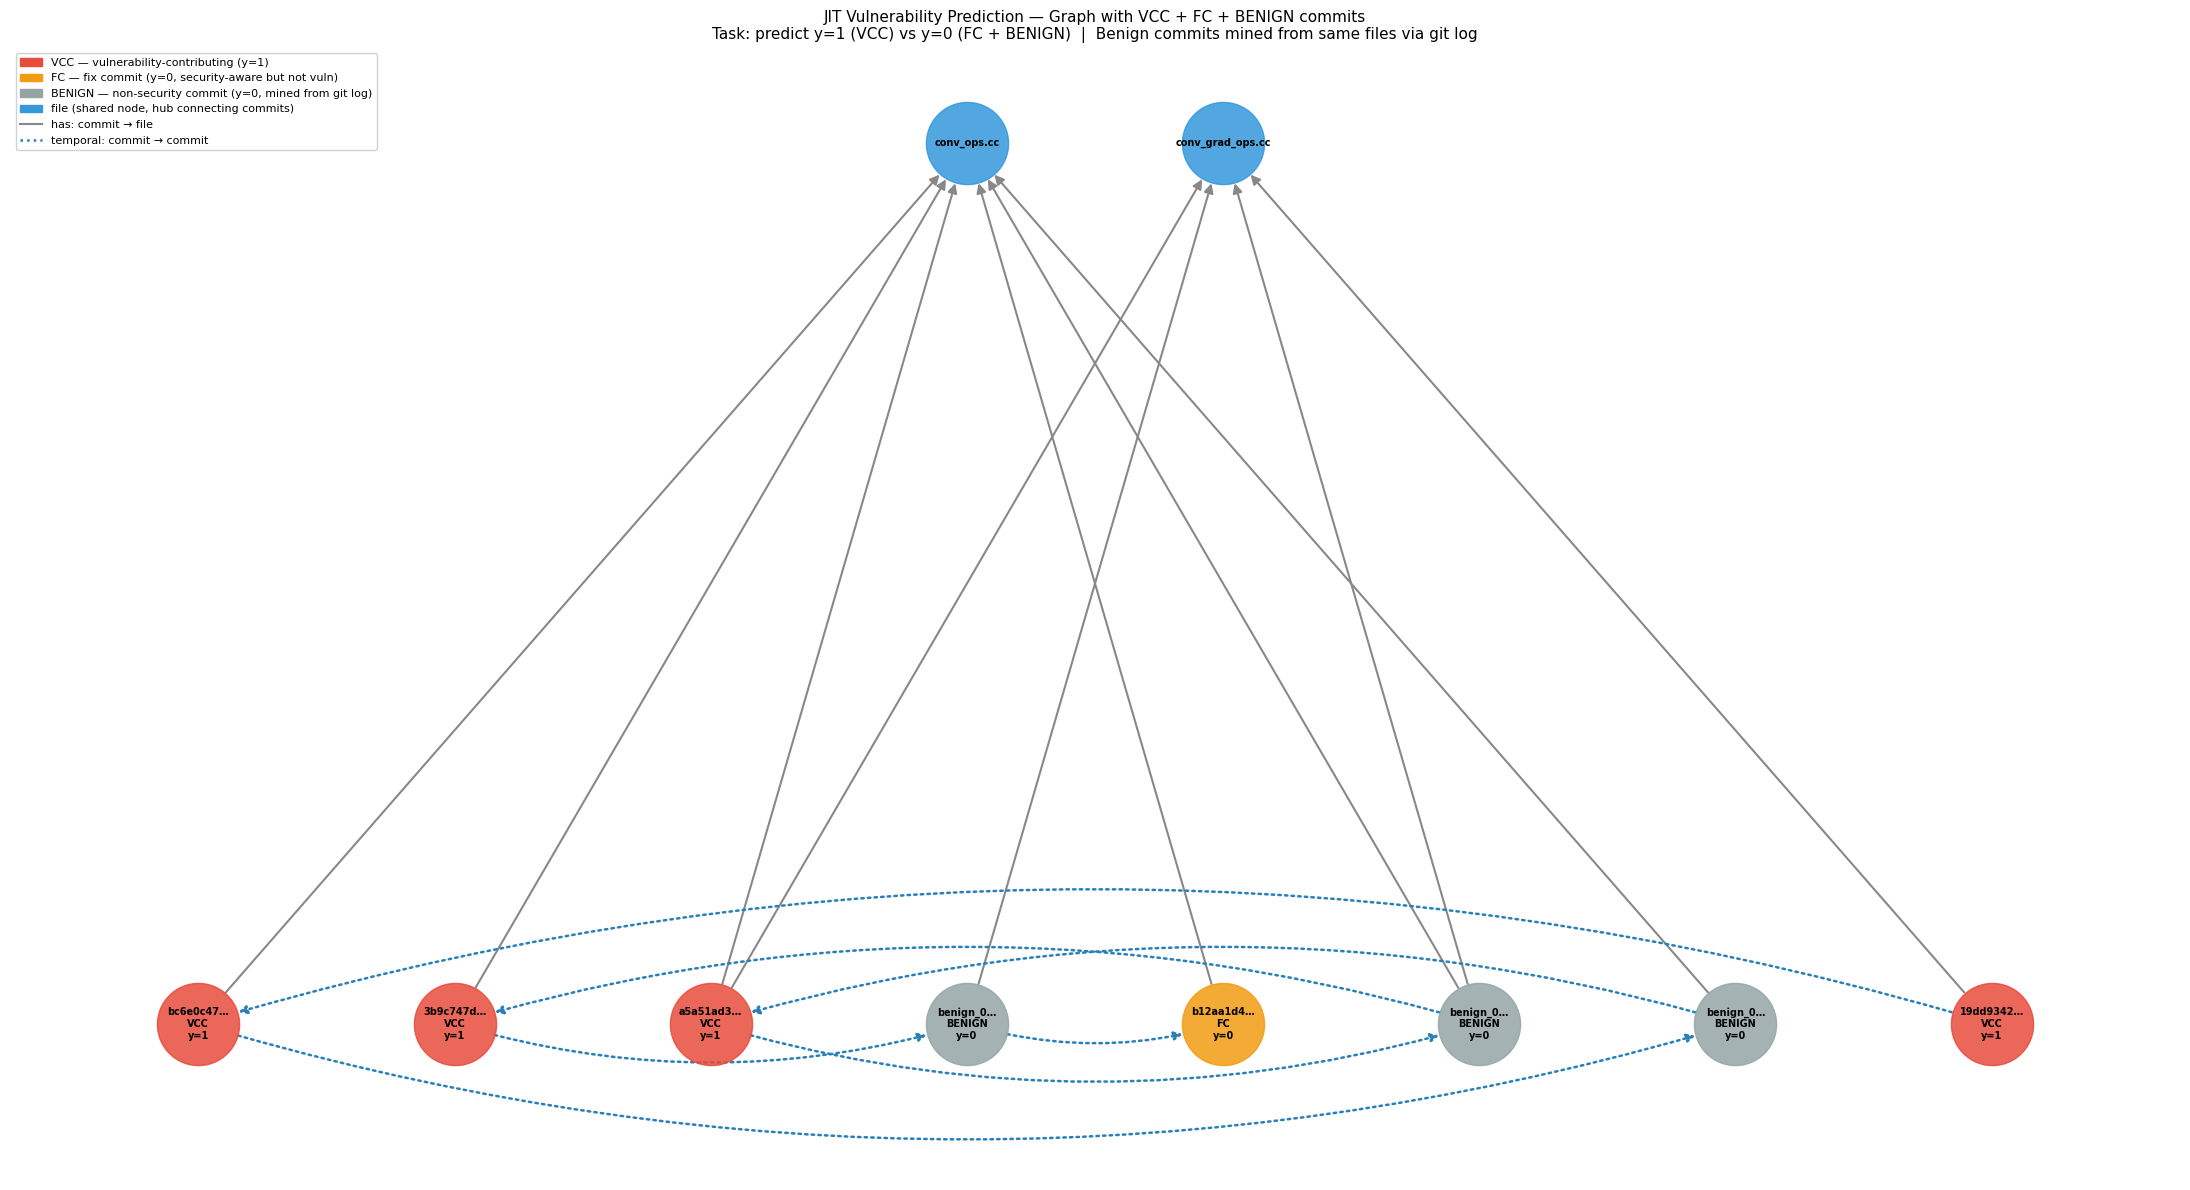


HOW TO MINE BENIGN COMMITS:

1. Clone TF repo:
   git clone --filter=blob:none https://github.com/tensorflow/tensorflow

2. For each security-relevant file, get all commits:
   git log --format="%H" -- tensorflow/core/kernels/conv_ops.cc

3. Remove hashes already in your VCC/FC set

4. Use pydriller to extract the same features:
   - commit metadata (lines added/deleted, author, date, ...)
   - file-level info (change_type, LOC, complexity, ...)
   - function-level info (parsed with tree-sitter or similar)

5. Add them to your CSVs with commit_type="BENIGN"

6. Label: VCC → y=1, FC+BENIGN → y=0

Sampling strategy:
  - Mine commits that touch the SAME files as VCCs (hard negatives)
  - Sample ~2-3x the number of VCCs (~1000-1400)
  - Maintain temporal distribution (don't over-sample from one period)



In [57]:
# ══════════════════════════════════════════════════════════════════════════════
# EXAMPLE: What a JIT-VP graph with benign commits looks like
# ══════════════════════════════════════════════════════════════════════════════
# We simulate 3 benign commits that touch the same files as our 5 selected commits,
# to show how the graph structure would look with 3 classes.

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Use our existing 5 commits + 3 simulated benign ones
existing = mc_commits[["hash", "commit_type", "author_date"]].copy()
existing["label"] = existing["commit_type"].map({"VCC": 1, "FC": 0})

# Simulate 3 benign commits touching the same files
# (In practice these come from `git log -- conv_ops.cc` minus VCC/FC hashes)
benign_examples = pd.DataFrame({
    "hash": ["benign_001_fake", "benign_002_fake", "benign_003_fake"],
    "commit_type": ["BENIGN", "BENIGN", "BENIGN"],
    "author_date": pd.to_datetime(["2018-01-15", "2018-06-20", "2019-02-10"], utc=True),
    "label": [0, 0, 0]  # non-vulnerable
})

all_commits = pd.concat([existing, benign_examples], ignore_index=True)
all_commits = all_commits.sort_values("author_date").reset_index(drop=True)

# Simulated file connections for benign commits
# (they touch conv_ops.cc or conv_grad_ops.cc — same files as VCCs/FCs)
benign_file_map = {
    "benign_001_fake": ["conv_ops.cc"],              # touches same file as 4 VCCs
    "benign_002_fake": ["conv_ops.cc", "conv_grad_ops.cc"],  # touches both
    "benign_003_fake": ["conv_grad_ops.cc"],          # touches same file as VCC + FC
}

# ── Build example graph ──────────────────────────────────────────────────────

G_example = nx.DiGraph()

# Commit nodes
color_by_type = {"VCC": "#e74c3c", "FC": "#f39c12", "BENIGN": "#95a5a6"}
for i, row in all_commits.iterrows():
    ctype = row["commit_type"]
    h = row["hash"][:8] + "…" if len(row["hash"]) > 8 else row["hash"]
    label = f"{h}\n{ctype}\ny={int(row['label'])}"
    G_example.add_node(f"c_{i}", layer=0, label=label, ntype=ctype)

# File nodes (shared, same 2 files)
for fn in ["conv_ops.cc", "conv_grad_ops.cc"]:
    G_example.add_node(f"f_{fn}", layer=1, label=fn, ntype="file")

# Edges: existing commits → files (from mc_files)
for i, row in all_commits.iterrows():
    h = row["hash"]
    if h in benign_file_map:
        for fn in benign_file_map[h]:
            G_example.add_edge(f"c_{i}", f"f_{fn}", etype="has")
    else:
        # Real commits — use mc_files
        commit_files = mc_files[mc_files["hash"] == h]["filename"].tolist()
        for fn in commit_files:
            if fn in ["conv_ops.cc", "conv_grad_ops.cc"]:
                G_example.add_edge(f"c_{i}", f"f_{fn}", etype="has")

# Temporal chain
for i in range(len(all_commits) - 1):
    G_example.add_edge(f"c_{i}", f"c_{i+1}", etype="temporal")

# ── Visualize ────────────────────────────────────────────────────────────────

pos = nx.multipartite_layout(G_example, subset_key="layer", scale=4, align="horizontal")
for node, (x, y) in pos.items():
    pos[node] = (x, y * 2.5)

fig, ax = plt.subplots(figsize=(22, 12))

# Edges
has_e = [(u, v) for u, v, d in G_example.edges(data=True) if d["etype"] == "has"]
temp_e = [(u, v) for u, v, d in G_example.edges(data=True) if d["etype"] == "temporal"]

nx.draw_networkx_edges(G_example, pos, edgelist=has_e, edge_color="#888888",
                       arrows=True, arrowsize=14, width=1.5, ax=ax,
                       min_target_margin=30, min_source_margin=30)
nx.draw_networkx_edges(G_example, pos, edgelist=temp_e, edge_color="#2980b9",
                       arrows=True, arrowsize=12, width=1.8, style="dotted",
                       connectionstyle="arc3,rad=0.15", ax=ax,
                       min_target_margin=30, min_source_margin=30)

# Nodes — color by type
for ntype, color in {**color_by_type, "file": "#3498db"}.items():
    nodes = [n for n, d in G_example.nodes(data=True) if d["ntype"] == ntype]
    nx.draw_networkx_nodes(G_example, pos, nodelist=nodes, node_color=color,
                           node_size=3500, alpha=0.85, ax=ax)

labels = {n: d["label"] for n, d in G_example.nodes(data=True)}
nx.draw_networkx_labels(G_example, pos, labels=labels, font_size=7,
                        font_weight="bold", ax=ax)

# Legend
legend_handles = [
    mpatches.Patch(color="#e74c3c", label="VCC — vulnerability-contributing (y=1)"),
    mpatches.Patch(color="#f39c12", label="FC — fix commit (y=0, security-aware but not vuln)"),
    mpatches.Patch(color="#95a5a6", label="BENIGN — non-security commit (y=0, mined from git log)"),
    mpatches.Patch(color="#3498db", label="file (shared node, hub connecting commits)"),
    plt.Line2D([0], [0], color="#888888", lw=1.5, label="has: commit → file"),
    plt.Line2D([0], [0], color="#2980b9", lw=1.8, linestyle="dotted", label="temporal: commit → commit"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=8, framealpha=0.9)
ax.set_title("JIT Vulnerability Prediction — Graph with VCC + FC + BENIGN commits\n"
             "Task: predict y=1 (VCC) vs y=0 (FC + BENIGN)  |  "
             "Benign commits mined from same files via git log",
             fontsize=11)
ax.axis("off")
fig.tight_layout()
plt.show()

print("\n" + "="*70)
print("HOW TO MINE BENIGN COMMITS:")
print("="*70)
print("""
1. Clone TF repo:
   git clone --filter=blob:none https://github.com/tensorflow/tensorflow

2. For each security-relevant file, get all commits:
   git log --format="%H" -- tensorflow/core/kernels/conv_ops.cc

3. Remove hashes already in your VCC/FC set

4. Use pydriller to extract the same features:
   - commit metadata (lines added/deleted, author, date, ...)
   - file-level info (change_type, LOC, complexity, ...)
   - function-level info (parsed with tree-sitter or similar)

5. Add them to your CSVs with commit_type="BENIGN"

6. Label: VCC → y=1, FC+BENIGN → y=0

Sampling strategy:
  - Mine commits that touch the SAME files as VCCs (hard negatives)
  - Sample ~2-3x the number of VCCs (~1000-1400)
  - Maintain temporal distribution (don't over-sample from one period)
""")
